# Trans Fictício BR — Validação da Camada Silver
<a id="topo"></a>

[Home](../README.md) | [← Avaliação de Qualidade de Dados](00_eda_qualidade_dados_ope.ipynb)

**Autor:** Tiago Lima
**Projeto:** Logística OTIF · Ciência de Dados & MLOps ponta a ponta
**Cliente:** Trans Fictício BR
**Data:** 19/08/2026

**Objetivo:** provar, com evidência reproduzível, que a camada Silver fez exatamente o que a avaliação de qualidade mandou fazer: **nem mais, nem menos**. A empresa é fictícia e todos os dados são sintéticos.

**O que este documento é.** A avaliação de qualidade (documento anterior) apontou defeitos e registrou ações. A camada Silver executou essas ações. Este notebook é a **prestação de contas** dessa execução, e ele existe porque a pergunta que o cliente faz depois de uma limpeza nunca é "você limpou?", é **"o que você mexeu nos meus dados?"**.

**Por que a prestação de contas é obrigatória.** Um pipeline de limpeza tem dois modos de falhar, e o segundo é muito pior:

1. **não corrigir o que devia.** É visível: o defeito continua lá, alguém reclama;
2. **corrigir o que não devia.** É invisível: o número fica bonito, o relatório fecha, e o dado está errado. Ausência preenchida com valor inventado, cadastro fundido por engano, categoria renomeada até virar outra coisa. Ninguém percebe, porque não há mais com o que comparar.

Este notebook foi escrito para pegar o **segundo** caso. Ele não pergunta "o Silver ficou limpo?", pergunta **"o que o Silver fez com cada célula que tocou, e o que ele fez com as que não devia tocar?"**.

**Perguntas-guia desta etapa:**
- O grão foi preservado, ou o Silver agregou alguma coisa por conta própria?
- Quais colunas foram alteradas, e quantas células em cada uma?
- Cada achado registrado na avaliação de qualidade foi de fato tratado?
- O que estava ausente continua ausente, ou a limpeza inventou dado?
- Rodar o pipeline duas vezes produz o mesmo resultado?

**Como este documento é organizado:** cada seção abre com o que será examinado, mostra a evidência em código e fecha com uma **Nota Técnica** contendo o que foi observado, por que importa e qual a ação.

## Sumário

| Seção | O que examina |
|---|---|
| [1. Imports e configurações](#secao-1) | ambiente e reprodutibilidade |
| [2. As duas fotografias](#secao-2) | de qual carga e de qual processamento estamos falando |
| [3. Carga das duas camadas](#secao-3) | Bronze e Silver lado a lado |
| [4. O grão foi preservado?](#secao-4) | uma linha entrou, uma linha saiu |
| [5. Onde o Silver mexeu](#secao-5) | o mapa de ajustes, tabela por tabela e coluna por coluna |
| [6. Texto conformado](#secao-6) | cidade, logradouro e recebedor: antes e depois |
| [7. Documento e CEP](#secao-7) | inclusive o tratamento que não teve efeito |
| [8. A chave de endereço](#secao-8) | duplicidade marcada, não fundida |
| [9. Nenhuma ausência criada nem destruída](#secao-9) | o teste que pega o pior tipo de erro |
| [10. O mesmo resultado toda vez](#secao-10) | idempotência |
| [11. Fechamento](#secao-11) | achado por achado, o que foi feito |

<a id="secao-1"></a>

# 1. Imports e Configurações

O acesso aos dados nunca é feito por caminho cru nem por credencial escrita aqui, tudo passa pelo pacote do projeto. Assim este notebook roda na máquina de qualquer pessoa que tenha o repositório, sem editar uma linha.

Repare que este notebook importa as **mesmas funções que o pipeline usa**, não uma cópia delas. Validar com código reescrito seria testar duas implementações diferentes: se as duas concordassem, provaria apenas que erramos igual nas duas.

## 1.1. Imports

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from logistica_otif_mlops import transformacoes as tr
from logistica_otif_mlops.pipelines.silver import REGRAS

## 1.2. Configurações Gerais

In [2]:
RAIZ = Path.cwd().parents[1] if Path.cwd().name == "operacional" else Path.cwd()
BRONZE = RAIZ / "data" / "bronze" / "operacao"
SILVER = RAIZ / "data" / "silver" / "operacao"

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# caminho relativo à raiz: o notebook vai para repositório público, e o caminho
# absoluto exporia a estrutura da máquina de quem executou
print(f"Bronze: {BRONZE.relative_to(RAIZ)}")
print(f"Silver: {SILVER.relative_to(RAIZ)}")

Bronze: data/bronze/operacao
Silver: data/silver/operacao


## Nota Técnica

**Observado:** o notebook carrega as mesmas funções de transformação usadas pelo pipeline (`transformacoes` e `REGRAS`), e lê as duas camadas por caminho relativo à raiz do projeto.

**Por que importa:** importar a implementação real, em vez de reescrever a regra aqui, é o que faz desta validação uma auditoria e não uma segunda opinião. Se a regra mudar amanhã, este notebook acusa a mudança sozinho.

**Ação:** nenhuma, é a configuração esperada.

<a id="secao-2"></a>

# 2. As duas fotografias

O Bronze tem o manifesto da **ingestão** (de onde veio, quando, quantas linhas). O Silver tem o manifesto do **processamento** (o que foi ajustado, em qual coluna, quantas células). Os dois são lidos, nunca digitados: número escrito à mão em documento envelhece no dia seguinte e passa a mentir.

O manifesto do Silver é a peça central deste notebook. Ele é gerado pelo próprio pipeline, na mesma execução que gravou os arquivos, então não existe a possibilidade de o relatório descrever uma execução e os dados serem de outra.

In [3]:
manifesto_bronze = json.loads((BRONZE.parent / "_manifesto.json").read_text(encoding="utf-8"))
manifesto_silver = json.loads((SILVER.parent / "_manifesto.json").read_text(encoding="utf-8"))

print(f"Bronze ingerido em:    {manifesto_bronze['carga_concluida_em']}")
print(f"Silver processado em:  {manifesto_silver['processado_em']}")
print(f"Duração do Silver:     {manifesto_silver['duracao_segundos']}s")

tratamentos = pd.DataFrame(manifesto_silver["tabelas"])
print(f"\nTabelas processadas:   {len(tratamentos)}")
print(f"Linhas no Silver:      {tratamentos['linhas'].sum():,.0f}")
print(f"Células ajustadas:     {tratamentos['total_ajustes'].sum():,.0f}")

tratamentos[["tabela", "linhas", "total_ajustes"]].sort_values(
    "total_ajustes", ascending=False)

Bronze ingerido em:    2026-08-18T18:54:23.511246+00:00
Silver processado em:  2026-08-20T12:16:52.717917+00:00
Duração do Silver:     9.5s

Tabelas processadas:   18
Linhas no Silver:      31,132,247
Células ajustadas:     194,683


,tabela,linhas,total_ajustes
1,entrega,2664991,168523
0,endereco,19697,25326
7,ocorrencia,48793,834
2,estoque_snapshot,56008,0
4,item,6804,0
3,fase,10,0
5,minuta,214692,0
6,modalidade,2,0
8,ordem_coleta,3662275,0
9,organizacao,240,0


## Nota Técnica

**Observado:** o Silver processou as 18 tabelas do operacional em poucos segundos e ajustou 194.683 células. O denominador correto para essa contagem é a **célula**, não a linha: o tratamento age em campo, e dividir por linha inflaria a proporção em tantas vezes quantas forem as colunas da tabela. Sobre as 189.985.538 células do domínio operacional, a proporção é de **0,1025%**, ou **1 célula em cada 975**.

**Por que importa:** a proporção é a primeira evidência de que a limpeza foi cirúrgica. Um pipeline que alterasse 10% das células não estaria limpando, estaria reescrevendo a base, e o dado deixaria de ser do cliente para passar a ser nosso. O manifesto sai da mesma execução que gravou os arquivos, então relatório e dado nunca divergem.

**Ação:** nenhuma. O manifesto é a referência de tudo que vem a seguir.

<a id="secao-3"></a>

# 3. Carga das duas camadas

As 18 tabelas de cada camada entram de uma vez, em dois dicionários. Carregar as duas juntas é o que permite a comparação célula a célula: sem o Bronze do lado, o Silver é apenas um conjunto de arquivos bonitos, sem nada que prove o que foi feito com eles.

In [4]:
bronze = {p.stem: pd.read_parquet(p) for p in sorted(BRONZE.glob("*.parquet"))}
silver = {p.stem: pd.read_parquet(p) for p in sorted(SILVER.glob("*.parquet"))}

print(f"Bronze: {len(bronze)} tabelas · {sum(len(d) for d in bronze.values()):,} linhas")
print(f"Silver: {len(silver)} tabelas · {sum(len(d) for d in silver.values()):,} linhas")
print(f"Mesmas tabelas nas duas camadas: {set(bronze) == set(silver)}")

Bronze: 18 tabelas · 31,132,247 linhas
Silver: 18 tabelas · 31,132,247 linhas
Mesmas tabelas nas duas camadas: True


## Nota Técnica

**Observado:** as duas camadas têm as mesmas 18 tabelas e o mesmo total de linhas.

**Por que importa:** o Silver **não** é o lugar de decidir o que entra na análise. Se uma tabela sumisse aqui, a decisão de descartá-la teria sido tomada dentro do tratamento, escondida de quem lê. Descarte é decisão de negócio, pertence ao Gold e precisa de justificativa escrita.

**Ação:** nenhuma.

<a id="secao-4"></a>

# 4. O grão foi preservado?

O Silver conforma, o Gold transforma. A fronteira entre os dois é o **grão**: `pedido` continua sendo uma linha por pedido, `pedido_fase` continua sendo uma linha por passagem de fase. Se o Silver agregasse, a granularidade se perderia, e com ela as features do modelo, porque agregação é irreversível.

A verificação abaixo compara a contagem de linhas e a de colunas. As colunas do Silver podem ser **mais** (a `chave_endereco` e a técnica `_processado_em` nascem aqui), nunca menos: coluna que some é informação descartada sem registro.

In [5]:
grao = pd.DataFrame([
    {
        "tabela": nome,
        "linhas_bronze": len(bronze[nome]),
        "linhas_silver": len(silver[nome]),
        "colunas_bronze": len(bronze[nome].columns),
        "colunas_silver": len(silver[nome].columns),
        "novas": ", ".join(sorted(set(silver[nome].columns) - set(bronze[nome].columns))),
        "perdidas": ", ".join(sorted(set(bronze[nome].columns) - set(silver[nome].columns))),
    }
    for nome in sorted(bronze)
])
grao["grao_ok"] = grao["linhas_bronze"] == grao["linhas_silver"]

print(f"Tabelas com grão preservado: {int(grao['grao_ok'].sum())} de {len(grao)}")
print(f"Tabelas com coluna perdida:  {int((grao['perdidas'] != '').sum())}")
grao[["tabela", "linhas_bronze", "linhas_silver", "grao_ok", "novas", "perdidas"]]

Tabelas com grão preservado: 18 de 18
Tabelas com coluna perdida:  0


,tabela,linhas_bronze,linhas_silver,grao_ok,novas,perdidas
0,endereco,19697,19697,True,"_processado_em, chave_endereco",
1,entrega,2664991,2664991,True,_processado_em,
2,estoque_snapshot,56008,56008,True,_processado_em,
3,fase,10,10,True,_processado_em,
4,item,6804,6804,True,_processado_em,
5,minuta,214692,214692,True,_processado_em,
6,modalidade,2,2,True,_processado_em,
7,ocorrencia,48793,48793,True,_processado_em,
8,ordem_coleta,3662275,3662275,True,_processado_em,
9,organizacao,240,240,True,_processado_em,


## Nota Técnica

**Observado:** as 18 tabelas mantiveram exatamente a mesma contagem de linhas. Nenhuma coluna foi perdida. As únicas colunas novas são a `_processado_em`, que é técnica, e a `chave_endereco`, que é derivada e aditiva.

**Por que importa:** grão preservado é o que garante que qualquer número do Gold pode ser aberto até o registro individual. É também o que separa uma camada Silver de uma camada de relatório: se o tratamento já entregasse o dado agregado, todo relatório novo teria que voltar ao Bronze, e a rastreabilidade morreria no meio do caminho.

**Ação:** nenhuma. Esta verificação deve entrar na suíte de testes automatizados do pipeline, para que uma agregação acidental quebre a CI em vez de chegar ao cliente.

<a id="secao-5"></a>

# 5. Onde o Silver mexeu

O manifesto guarda a contagem de células alteradas **por coluna**, não só por tabela. Esse detalhe é o que transforma "normalizamos o cadastro" (afirmação sem tamanho) em "alteramos 168.523 células da coluna `recebedor`" (afirmação verificável).

Ele serve também de alarme: tratamento que mexe em coluna inesperada aparece nesta lista antes de virar problema no relatório.

In [6]:
ajustes = pd.DataFrame([
    {"tabela": item["tabela"], "coluna": coluna, "celulas": quantidade}
    for item in manifesto_silver["tabelas"]
    for coluna, quantidade in item["colunas_ajustadas"].items()
]).sort_values("celulas", ascending=False)

total = ajustes["celulas"].sum()
print(f"{len(ajustes)} colunas alteradas em {ajustes['tabela'].nunique()} tabelas")
print(f"{total:,} células no total")
ajustes.assign(percentual=lambda d: d["celulas"] / total * 100)

5 colunas alteradas em 3 tabelas
194,683 células no total


,tabela,coluna,celulas,percentual
3,entrega,recebedor,168523,86.56
1,endereco,logradouro,12473,6.41
0,endereco,nome_local,7000,3.60
2,endereco,cidade,5853,3.01
4,ocorrencia,observacao,834,0.43


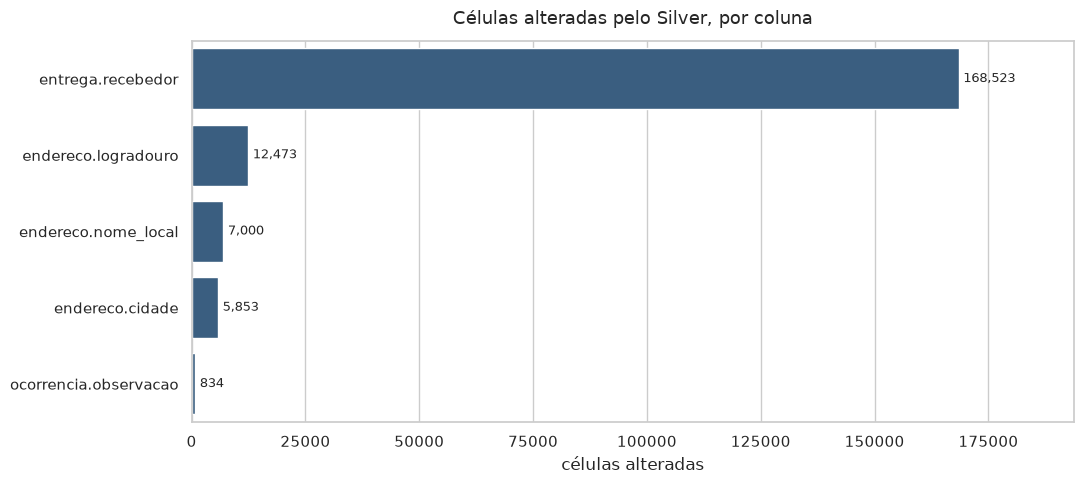

In [7]:
fig, eixo = plt.subplots(figsize=(11, 5))
dados = ajustes.assign(rotulo=lambda d: d["tabela"] + "." + d["coluna"])
sns.barplot(data=dados, y="rotulo", x="celulas", color="#2E5E8C", ax=eixo)
eixo.set_title("Células alteradas pelo Silver, por coluna", fontsize=13, pad=12)
eixo.set_xlabel("células alteradas")
eixo.set_ylabel("")
for barra, valor in zip(eixo.patches, dados["celulas"]):
    eixo.text(barra.get_width() + total * 0.005,
              barra.get_y() + barra.get_height() / 2,
              f"{valor:,}", va="center", fontsize=9)
eixo.set_xlim(0, dados["celulas"].max() * 1.15)
plt.tight_layout()
plt.show()

## Nota Técnica

**Observado:** o tratamento se concentrou em pouquíssimos lugares. A coluna `entrega.recebedor` responde sozinha por 168.523 das 194.683 células alteradas, e as demais são todas de `endereco` e de `ocorrencia.observacao`. Nenhuma coluna numérica, de data ou de chave foi tocada.

**Por que importa:** esta é a evidência mais forte do notebook, e vale pelo que **não** aparece na lista. Peso, volume, valor, data e chave estrangeira passaram intactos. Se qualquer uma delas aparecesse aqui, o indicador do relatório final teria sido alterado pela limpeza, e a diferença seria impossível de explicar ao cliente depois.

**Ação:** nenhuma. A lista confirma que o escopo do tratamento é o texto digitado por pessoas, que era exatamente o diagnóstico da avaliação de qualidade.

<a id="secao-6"></a>

# 6. Texto conformado

Os três achados de texto da avaliação de qualidade, um por vez, com o antes e o depois. A função `chave_comparacao` é o instrumento de medida: ela reduz o texto à forma comparável (sem acento, sem caixa, sem pontuação), e é assim que se descobre que duas grafias são a mesma coisa.

## 6.1. Cidade em várias grafias

O caso clássico. A mesma cidade cadastrada de quatro jeitos vira quatro cidades em qualquer agrupamento geográfico, e o mapa do relatório fica errado sem que ninguém desconfie.

In [8]:
def variantes(serie: pd.Series) -> dict[str, set[str]]:
    """Agrupa as grafias distintas que se referem ao mesmo valor."""
    mapa: dict[str, set[str]] = {}
    for valor in serie.dropna().astype(str).unique():
        mapa.setdefault(tr.chave_comparacao(valor), set()).add(valor)
    return {chave: grafias for chave, grafias in mapa.items() if len(grafias) > 1}


for campo in ("cidade", "bairro", "nome_local"):
    vb = variantes(bronze["endereco"][campo])
    vs = variantes(silver["endereco"][campo])
    print(f"{campo:<12} bronze: {len(vb):>3} valores em grafia múltipla | "
          f"silver: {len(vs):>3}")

print()
chave_sp = tr.chave_comparacao("São Paulo")
for rotulo, camada in (("bronze", bronze), ("silver", silver)):
    df = camada["endereco"]
    grafias = sorted(df[df["cidade"].map(tr.chave_comparacao) == chave_sp]["cidade"].unique())
    print(f"São Paulo no {rotulo}: {grafias}")

cidade       bronze:  65 valores em grafia múltipla | silver:   0
bairro       bronze:   0 valores em grafia múltipla | silver:   0
nome_local   bronze:  56 valores em grafia múltipla | silver:   0



São Paulo no bronze: ['SAO PAULO', 'Sao Paulo', 'SÃO PAULO', 'São Paulo']
São Paulo no silver: ['São Paulo']


## Nota Técnica

**Observado:** as 65 cidades e os 56 nomes de local que apareciam em mais de uma grafia no Bronze foram reduzidos a zero. São Paulo, que estava cadastrada como `SAO PAULO`, `Sao Paulo`, `SÃO PAULO` e `São Paulo`, ficou com uma única forma, **com acento**, e o mesmo aconteceu com pares como `Farmacia Popular` e `Farmácia Popular`.

**Por que importa:** a capitalização sozinha não resolveria isto. Ela conserta caixa e espaço, mas não devolve o acento que nunca foi digitado, e `Sao Paulo` continuaria separada de `São Paulo`. Foi preciso eleger uma grafia oficial por grupo, e o critério de eleição importa: **quem tem acento ganha**, porque digitar sem acento é o erro comum e ninguém acentua por engano. A eleição sai dos próprios dados, sem lista externa de municípios, o que mantém o método aplicável a qualquer base de cliente.

**Ação:** nenhuma no dado. Vale registrar no relatório ao cliente que o cadastro de origem continua aceitando grafia livre, e que o problema volta na próxima carga enquanto o sistema não tiver validação na entrada.

## 6.2. Logradouro abreviado

`R. das Flores` e `Rua das Flores` são o mesmo endereço para uma pessoa e dois endereços para um agrupamento. A comparação abaixo é feita sem diferenciar maiúscula de minúscula, porque a base escreve a abreviação dos dois jeitos.

In [9]:
padrao_abreviado = r"^(r\.|av\.|rod\.|tv\.|est\.|al\.|pç\.|pc\.)"
padrao_extenso = r"^(rua|avenida|rodovia|travessa|estrada|alameda|praça)"

for rotulo, camada in (("bronze", bronze), ("silver", silver)):
    serie = camada["endereco"]["logradouro"].dropna().astype(str)
    abreviados = int(serie.str.match(padrao_abreviado, case=False).sum())
    extensos = int(serie.str.match(padrao_extenso, case=False).sum())
    print(f"{rotulo}: {abreviados:>6,} abreviados | {extensos:>6,} por extenso | "
          f"{len(serie):>6,} no total")

print("\nExemplos do mesmo registro nas duas camadas:")
amostra = bronze["endereco"]["logradouro"].str.match(padrao_abreviado, case=False).fillna(False)
pd.DataFrame({
    "bronze": bronze["endereco"].loc[amostra, "logradouro"].head(8).to_numpy(),
    "silver": silver["endereco"].loc[amostra, "logradouro"].head(8).to_numpy(),
})

bronze: 10,097 abreviados |  9,600 por extenso | 19,697 no total
silver:      0 abreviados | 19,697 por extenso | 19,697 no total

Exemplos do mesmo registro nas duas camadas:


,bronze,silver
0,Av. Paulista 2925,Avenida Paulista 2925
1,"Rod. Anhanguera, km 4616","Rodovia Anhanguera, KM 4616"
2,Av. das Nações 2013,Avenida das Nações 2013
3,AV. DAS NAÇÕES 2955,Avenida das Nações 2955
4,Av. Paulista 4400,Avenida Paulista 4400
5,R. das Acácias 1024,Rua das Acácias 1024
6,AV. INDUSTRIAL 4948,Avenida Industrial 4948
7,"Rod. Anhanguera, km 4152","Rodovia Anhanguera, KM 4152"


## Nota Técnica

**Observado:** os 10.097 logradouros abreviados foram expandidos. Os 19.697 endereços da base estão agora com o tipo por extenso.

**Por que importa:** endereço é a chave de junção com qualquer fonte geográfica externa (CEP, geocodificação, malha de rotas). Enquanto o mesmo lugar existir em duas escritas, metade das junções falha silenciosamente, e o custo por rota sai errado sem gerar erro em lugar nenhum.

**Ação:** nenhuma. A tabela de abreviações fica em `transformacoes.py` e cresce por evidência: abreviação nova encontrada em base de cliente entra lá com teste próprio.

## 6.3. Recebedor

O nome de quem assinou o canhoto, digitado no aplicativo do motorista, na chuva, com o dedo. É o campo mais frágil da base inteira e o que mais recebeu ajuste.

In [10]:
for rotulo, camada in (("bronze", bronze), ("silver", silver)):
    serie = camada["entrega"]["recebedor"].dropna().astype(str)
    print(f"{rotulo}: {int((serie == serie.str.upper()).sum()):>8,} em CAIXA ALTA | "
          f"{int((serie != serie.str.strip()).sum()):>7,} com espaço nas pontas | "
          f"{serie.nunique():>4} nomes distintos")

print("\nOs nomes que sobraram no Silver:")
print(sorted(silver["entrega"]["recebedor"].dropna().unique())[:20])

bronze:  101,065 em CAIXA ALTA |  42,147 com espaço nas pontas |   56 nomes distintos


silver:        0 em CAIXA ALTA |       0 com espaço nas pontas |   32 nomes distintos

Os nomes que sobraram no Silver:
['Ana', 'Ana Santos', 'Ana Silva', 'Ana Souza', 'Carlos', 'Carlos Santos', 'Carlos Silva', 'Carlos Souza', 'Fernanda', 'Fernanda Santos', 'Fernanda Silva', 'Fernanda Souza', 'José', 'José Santos', 'José Silva', 'José Souza', 'Luiz', 'Luiz Santos', 'Luiz Silva', 'Luiz Souza']


## Nota Técnica

**Observado:** os 56 nomes distintos do Bronze eram, na verdade, 32 pessoas escritas de formas diferentes. Sumiram as 101.065 ocorrências em caixa alta e os 42.147 espaços sobrando.

**Por que importa:** cada grafia a mais é uma pessoa a mais em qualquer contagem por recebedor. Um indicador de recorrência de recebedor no cliente estaria dividido por dois, e o erro seria invisível na tela porque `Maria Silva ` e `Maria Silva` parecem idênticos.

**Ação:** nenhuma no dado. A causa está na entrada do aplicativo do motorista, que aceita texto livre onde deveria haver seleção ou validação. Reportar ao dono do sistema.

<a id="secao-7"></a>

# 7. Documento e CEP, inclusive o tratamento que não teve efeito

Documento e CEP são normalizados para conter apenas dígitos: guardar só o número é o que permite comparar cadastros, porque com máscara o mesmo CNPJ aparece de três formas. A máscara é assunto de exibição e se reconstrói na hora de mostrar.

Esta seção também presta contas de uma coisa que raramente aparece em relatório de limpeza: **o tratamento que rodou e não encontrou nada para corrigir**.

In [11]:
for campo in ("documento", "cep"):
    for rotulo, camada in (("bronze", bronze), ("silver", silver)):
        serie = camada["endereco"][campo].dropna().astype(str)
        print(f"{campo:<10} {rotulo}: "
              f"{int(serie.str.contains(chr(92) + 'D').sum()):>6,} com máscara | "
              f"{serie.nunique():>6,} distintos")
    print()

# tratamentos que rodaram sem encontrar o que corrigir
sem_efeito = []
for nome in REGRAS:
    b, s = bronze[nome], silver[nome]
    for coluna in b.columns:
        if coluna.startswith("_") or coluna not in s.columns:
            continue
        alterados = int(((b[coluna] != s[coluna])
                         & ~(b[coluna].isna() & s[coluna].isna())).sum())
        sem_efeito.append({"tabela": nome, "coluna": coluna,
                           "alterados": alterados, "linhas": len(b)})

pd.DataFrame(sem_efeito).query("alterados == 0").reset_index(drop=True)

documento  bronze:      0 com máscara | 15,820 distintos
documento  silver:      0 com máscara | 15,820 distintos

cep        bronze:      0 com máscara | 19,671 distintos
cep        silver:      0 com máscara | 19,671 distintos



,tabela,coluna,alterados,linhas
0,endereco,id,0,19697
1,endereco,organizacao_id,0,19697
2,endereco,documento,0,19697
3,endereco,bairro,0,19697
4,endereco,uf,0,19697
5,endereco,cep,0,19697
6,endereco,latitude,0,19697
7,endereco,longitude,0,19697
8,endereco,fl_principal,0,19697
9,entrega,id,0,2664991


## Nota Técnica

**Observado:** documento e CEP já vinham no formato correto do sistema de origem: zero registros com máscara nas duas camadas, e a normalização não alterou nenhuma célula. O mesmo vale para `organizacao`, `transportador` e `item`, cujas regras rodaram sem encontrar o que corrigir.

**Por que importa:** reportar o tratamento que não teve efeito é uma questão de honestidade metodológica, e tem valor prático nos dois sentidos. Primeiro, mostra que o pipeline não inflou o número de correções para parecer útil. Segundo, essas regras são **defesa, não conserto**: elas existem para o dia em que a origem mudar, e são o que impede que uma mudança no sistema do cliente quebre o Gold sem aviso. Vale dizer com todas as letras que o CEP é tratado como texto e nunca como número, porque `01001000` convertido para inteiro vira `1001000` e deixa de ser um CEP.

**Ação:** manter as regras. Custo de execução desprezível, e a proteção contra mudança de origem é permanente. O teste unitário do zero à esquerda cobre o caso mesmo sem ele ocorrer nesta base.

<a id="secao-8"></a>

# 8. A chave de endereço: duplicidade marcada, não fundida

A avaliação de qualidade encontrou o mesmo endereço cadastrado mais de uma vez, com grafias diferentes. A tentação é fundir os cadastros duplicados. O Silver **não** faz isso, e a razão precisa estar escrita:

- apagar cadastro **quebra o histórico**, porque os pedidos antigos apontam para o registro que sumiria;
- decidir qual dos dois cadastros é o "verdadeiro" é **decisão do cliente**, não do pipeline;
- fusão errada é **irreversível** depois que o Bronze rotaciona.

Então o Silver faz o que cabe a ele: **marca**. A `chave_endereco` agrupa o que é o mesmo lugar e deixa a decisão para quem tem autoridade sobre o cadastro.

In [12]:
frequencia = silver["endereco"]["chave_endereco"].value_counts()
duplicados = frequencia[frequencia > 1]

print(f"Grupos com mais de um cadastro: {len(duplicados):,}")
print(f"Cadastros envolvidos:           {int(duplicados.sum()):,}")
print(f"Cadastros que seriam eliminados numa fusão: {int(duplicados.sum() - len(duplicados)):,}")
print(f"Total de endereços na base:     {len(silver['endereco']):,}")

exemplo = duplicados.index[0]
silver["endereco"].loc[
    silver["endereco"]["chave_endereco"] == exemplo,
    ["id", "nome_local", "logradouro", "cidade", "uf", "cep", "chave_endereco"],
]

Grupos com mais de um cadastro: 333
Cadastros envolvidos:           676
Cadastros que seriam eliminados numa fusão: 343
Total de endereços na base:     19,697


,id,nome_local,logradouro,cidade,uf,cep,chave_endereco
4079,11989,Loja Ideal,"Rua das Flores, 3796",São Paulo,SP,14922290,ruadasflores3796|saopaulo|SP
6296,8656,Distribuidora Popular,"Rua das Flores, 3796",São Paulo,SP,39095670,ruadasflores3796|saopaulo|SP
10265,14041,Distribuidora do Vale,"Rua das Flores, 3796",São Paulo,SP,87923380,ruadasflores3796|saopaulo|SP
18980,8609,Mercado do Vale,"Rua das Flores, 3796",São Paulo,SP,63304980,ruadasflores3796|saopaulo|SP


## Nota Técnica

**Observado:** 333 grupos reúnem 676 cadastros que apontam para o mesmo lugar físico. Uma fusão eliminaria 343 registros de endereço.

**Por que importa:** estes 343 registros são a diferença entre uma limpeza responsável e uma limpeza destrutiva. O pipeline tem informação suficiente para fundi-los e **escolhe não fazê-lo**, porque a informação de que dois cadastros são o mesmo lugar é diferente da autoridade para eliminar um deles. Marcar entrega ao cliente as duas coisas: o problema quantificado e a liberdade de decidir. Fundir entregaria só o resultado, sem volta.

**Ação:** levar os 333 grupos ao dono do cadastro para conferência e decisão. A partir do momento em que a decisão existir, ela vira regra explícita no Gold, com registro de quem decidiu e quando.

<a id="secao-9"></a>

# 9. Nenhuma ausência foi criada nem destruída

Esta é a seção mais importante do notebook, e ela nasceu de um erro real cometido durante o desenvolvimento deste pipeline.

O pandas, ao aplicar uma função sobre uma coluna de texto, **passa o valor ausente para a função** em vez de pulá-lo, e no caminho o ausente vira a string `"nan"`. A função de capitalizar recebeu `"nan"` e devolveu `"Nan"`, corretamente. Resultado: **1.239.076 ausências viraram um recebedor chamado "Nan"**.

O erro é grave por três motivos. Ele é silencioso, porque a coluna fica com aparência melhor do que antes. Ele é irreversível dentro do Silver, porque a ausência não pode ser recuperada de um texto. E ele destrói justamente o achado mais valioso da avaliação de qualidade, que era o fato de a transferência para base não registrar recebedor.

A correção foi pedir explicitamente ao pandas que pule os ausentes. A verificação abaixo é a que teria pego o erro no dia em que ele foi cometido, e por isso ela ficou.

### 9.1. A contagem de ausências mudou em alguma coluna?

In [13]:
comparacao = []
for nome in sorted(bronze):
    b, s = bronze[nome], silver[nome]
    for coluna in b.columns:
        if coluna.startswith("_") or coluna not in s.columns:
            continue
        nulos_b, nulos_s = int(b[coluna].isna().sum()), int(s[coluna].isna().sum())
        if nulos_b != nulos_s:
            comparacao.append({"tabela": nome, "coluna": coluna, "bronze": nulos_b,
                               "silver": nulos_s, "diferença": nulos_s - nulos_b})

divergencias = pd.DataFrame(comparacao)
print(f"Colunas com contagem de ausência alterada: {len(divergencias)}")
divergencias if len(divergencias) else "nenhuma coluna teve a contagem de ausência alterada"

Colunas com contagem de ausência alterada: 1


,tabela,coluna,bronze,silver,diferença
0,ocorrencia,observacao,0,717,717


### 9.2. Sobrou algum ausente disfarçado de texto?

In [14]:
disfarces = {"nan", "none", "nat", "null", "<na>", "n/a", "na", "-", ""}

encontrados = []
for nome, df in silver.items():
    for coluna in df.columns:
        if df[coluna].dtype not in ("str", "object"):
            continue
        serie = df[coluna].dropna().astype(str).str.strip().str.lower()
        quantidade = int(serie.isin(disfarces).sum())
        if quantidade:
            encontrados.append({"tabela": nome, "coluna": coluna, "ocorrências": quantidade})

print(f"Colunas com ausente disfarçado de texto: {len(encontrados)}")
pd.DataFrame(encontrados) if encontrados else "nenhum"

Colunas com ausente disfarçado de texto: 0


'nenhum'

### 9.3. Os dois achados que precisavam sobreviver intactos

In [15]:
recebedor_b = bronze["entrega"].loc[
    bronze["entrega"]["tipo_perna"] == "TRANSFERENCIA_BASE", "recebedor"].isna().sum()
recebedor_s = silver["entrega"].loc[
    silver["entrega"]["tipo_perna"] == "TRANSFERENCIA_BASE", "recebedor"].isna().sum()

print(f"transferência sem recebedor   bronze {recebedor_b:>9,} | silver {recebedor_s:>9,}")
print(f"item sem valor unitário       bronze "
      f"{int(bronze['item']['valor_unitario'].isna().sum()):>9,} | silver "
      f"{int(silver['item']['valor_unitario'].isna().sum()):>9,}")

transferência sem recebedor   bronze 1,239,076 | silver 1,239,076
item sem valor unitário       bronze       345 | silver       345


## Nota Técnica

**Observado:** uma única coluna teve a contagem de ausência alterada, `ocorrencia.observacao`, com 717 ausências a mais, e por decisão explícita. Nenhum ausente disfarçado de texto sobrou em nenhuma das 18 tabelas. Os dois achados que precisavam sobreviver sobreviveram na contagem exata: 1.239.076 transferências sem recebedor e 345 itens sem valor unitário.

**Por que importa:** as 717 ausências criadas em `observacao` são o inverso do erro do `\"Nan\"`, e valem como exemplo do critério. Ali havia texto livre com `-`, `N/A` e `sem informacao`, que são ausência disfarçada de conteúdo: mantê-los faria qualquer agrupamento por observação exibir `-` como se fosse uma categoria real de ocorrência. Converter para ausência **revela** a falta; preencher a ausência **esconde** a falta. A regra que governa as duas decisões é a mesma: nulo não é um valor, é a ausência de valor, e toda operação que o trata como valor inventa dado. É o mesmo motivo pelo qual, no SQL, `NULL = NULL` não é verdadeiro.

**Ação:** manter as três verificações desta seção na suíte de testes do pipeline. Elas são baratas de rodar e pegam a classe de erro mais cara de descobrir tarde.

<a id="secao-10"></a>

# 10. O mesmo resultado toda vez

Um tratamento precisa ser **idempotente**: aplicá-lo duas vezes tem que dar o mesmo resultado que aplicá-lo uma vez. Sem essa propriedade, reprocessar uma carga (que acontece o tempo todo, por falha de rede, correção de bug ou chegada de dado atrasado) produziria um resultado diferente do anterior, e ninguém saberia qual dos dois é o certo.

O teste é direto: aplicar as regras sobre o **Silver** e conferir que nada muda. Se alguma regra dependesse do estado anterior, ou usasse aleatoriedade, ou desempatasse por ordem de leitura, a diferença apareceria aqui.

In [16]:
idempotencia = []
for nome, regra in REGRAS.items():
    atual = silver[nome]
    reaplicado = regra(atual.copy(deep=True))
    diferentes = 0
    for coluna in atual.columns:
        if coluna.startswith("_"):
            continue
        a, b = atual[coluna], reaplicado[coluna]
        diferentes += int(((a != b) & ~(a.isna() & b.isna())).sum())
    idempotencia.append({"tabela": nome, "células_que_mudariam": diferentes,
                         "idempotente": diferentes == 0})

resultado = pd.DataFrame(idempotencia)
print(f"Regras idempotentes: {int(resultado['idempotente'].sum())} de {len(resultado)}")
resultado

Regras idempotentes: 7 de 7


,tabela,células_que_mudariam,idempotente
0,endereco,0,True
1,entrega,0,True
2,organizacao,0,True
3,item,0,True
4,transportador,0,True
5,veiculo,0,True
6,ocorrencia,0,True


## Nota Técnica

**Observado:** as sete regras de tratamento são idempotentes. Reaplicá-las sobre o Silver não altera uma única célula.

**Por que importa:** esta é a propriedade que torna o reprocessamento seguro, e ela não é automática. A eleição da grafia canônica, por exemplo, poderia facilmente não ser idempotente: se o critério de desempate fosse a ordem de leitura do arquivo, ou se houvesse qualquer sorteio, duas execuções elegeriam vencedores diferentes e o mesmo endereço mudaria de nome a cada carga. Por isso o desempate final da eleição é alfabético, que é uma ordem estável e não depende de como o dado chegou.

**Ação:** nenhuma. Esta verificação também deve entrar na suíte automatizada, porque a idempotência é fácil de quebrar sem perceber ao acrescentar uma regra nova.

<a id="secao-11"></a>

# 11. Fechamento

Achado por achado, o que a avaliação de qualidade mandou fazer e o que o Silver fez. A coluna de evidência aponta a seção deste notebook onde a afirmação pode ser conferida.

In [17]:
fechamento = pd.DataFrame([
    {"achado": "Cidade e nome de local em várias grafias", "severidade": "alta",
     "decisão": "conformar", "situação": "tratado",
     "evidência": "seção 6.1: 121 valores em grafia múltipla → 0"},
    {"achado": "Logradouro abreviado e por extenso", "severidade": "alta",
     "decisão": "conformar", "situação": "tratado",
     "evidência": "seção 6.2: 10.097 abreviados → 0"},
    {"achado": "Recebedor com caixa e espaço inconsistentes", "severidade": "média",
     "decisão": "conformar", "situação": "tratado",
     "evidência": "seção 6.3: 56 nomes distintos → 32"},
    {"achado": "Observação com texto sem conteúdo", "severidade": "baixa",
     "decisão": "converter em ausência", "situação": "tratado",
     "evidência": "seção 9.1: +717 ausências, deliberadas"},
    {"achado": "Endereço duplicado com grafias diferentes", "severidade": "alta",
     "decisão": "marcar, não fundir", "situação": "marcado",
     "evidência": "seção 8: 333 grupos, 676 cadastros"},
    {"achado": "Transferência para base sem recebedor", "severidade": "alta",
     "decisão": "não tratar, é achado de processo", "situação": "preservado",
     "evidência": "seção 9.3: 1.239.076 em ambas as camadas"},
    {"achado": "Item sem valor unitário", "severidade": "média",
     "decisão": "não tratar, depende do cliente", "situação": "preservado",
     "evidência": "seção 9.3: 345 em ambas as camadas"},
])

print(fechamento["situação"].value_counts().to_string())
fechamento

situação
tratado       4
preservado    2
marcado       1


,achado,severidade,decisão,situação,evidência
0,Cidade e nome de local em várias grafias,alta,conformar,tratado,seção 6.1: 121 valores em grafia múltipla → 0
1,Logradouro abreviado e por extenso,alta,conformar,tratado,seção 6.2: 10.097 abreviados → 0
2,Recebedor com caixa e espaço inconsistentes,média,conformar,tratado,seção 6.3: 56 nomes distintos → 32
3,Observação com texto sem conteúdo,baixa,converter em ausência,tratado,"seção 9.1: +717 ausências, deliberadas"
4,Endereço duplicado com grafias diferentes,alta,"marcar, não fundir",marcado,"seção 8: 333 grupos, 676 cadastros"
5,Transferência para base sem recebedor,alta,"não tratar, é achado de processo",preservado,seção 9.3: 1.239.076 em ambas as camadas
6,Item sem valor unitário,média,"não tratar, depende do cliente",preservado,seção 9.3: 345 em ambas as camadas


## Nota Técnica de fechamento

**O que foi validado:** as 18 tabelas do domínio operacional, 31,1 milhões de linhas, comparadas célula a célula entre o Bronze e o Silver. Sete achados da avaliação de qualidade foram acompanhados até o destino: quatro tratados, um marcado, dois preservados de propósito.

**O que o Silver fez:** alterou 194.683 células, 1 em cada 975 do domínio operacional, concentradas em cinco colunas de texto digitado por pessoas. Não tocou em nenhum valor numérico, nenhuma data, nenhuma chave.

**O que o Silver não fez, e é o mais importante:**

- não agregou nada, o grão das 18 tabelas está intacto;
- não descartou nenhuma tabela, linha ou coluna;
- não preencheu nenhuma ausência, e as 1.239.076 transferências sem recebedor chegaram inteiras ao outro lado;
- não fundiu cadastro duplicado, apenas marcou os 333 grupos e devolveu a decisão a quem tem autoridade sobre ela.

**Por que isso importa para o cliente:** a limpeza de dados é o momento em que um projeto de dados mais facilmente perde a confiança, porque é onde o consultor toca no dado do cliente sem que ele veja. Este documento existe para que ele veja. Todo número aqui é reproduzível a partir das mesmas duas camadas, e a comparação com o Bronze estará disponível enquanto o Bronze existir, que é a razão de o Bronze ser cópia fiel e intocável.

**A lição técnica que fica:** o erro mais caro deste pipeline não foi deixar de corrigir alguma coisa. Foi corrigir demais, uma vez, em silêncio: 1.239.076 ausências transformadas em um recebedor inexistente por uma decisão de comportamento padrão do pandas. Ele não foi encontrado por leitura de código, foi encontrado por comparação com a camada anterior. É o argumento prático a favor da arquitetura medallion, e a razão de esta validação ser uma etapa do processo, e não um extra.

**Ações que seguem para o cliente:**

1. **cadastro de endereço aceita grafia livre.** Os 333 grupos duplicados voltarão na próxima carga enquanto não houver validação na entrada. Levar ao dono do sistema;
2. **os 333 grupos precisam de decisão do cliente** sobre fusão, com registro de quem decidiu;
3. **a transferência para base não registra recebedor.** É achado de processo, não de dado, e a discussão pertence à operação;
4. **os 345 itens sem valor unitário** dependem de definição de regra pelo cliente antes de qualquer imputação.

**Próxima etapa:** camada Gold, onde as transformações de negócio acontecem (as fases viram colunas, as durações são calculadas e a régua de prazo é aplicada). É lá que o dado conformado vira o relatório que o Elias e a Dna. Sarah aprovaram.

---

[Início](#topo)